![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 1. Parte A: Fundamentos de PyTorch

**Asignatura:** Redes Neuronales Profundas 
**Bloque:** 1 — Fundamentos de Deep Learning 

---

## Introducción

PyTorch es el framework de deep learning más utilizado en investigación y se está volviendo dominante también en la industria. Toda red neuronal en PyTorch —sin importar su complejidad— se construye sobre un único concepto fundamental: el **tensor**.

Este trabajo práctico tiene como objetivo que te familiarices con las operaciones sobre tensores que más se usan en el día a día del deep learning:

- Crear y explorar tensores
- Cambiar su forma en memoria (`reshape`, `view`, `unsqueeze`)
- Entender cómo PyTorch opera tensores de distintas formas (*broadcasting*)
- Calcular derivadas automáticamente con `autograd`

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Para resolver cada ejercicio, consultá el material teórico de la Clase 1.
- **No está permitido usar bucles `for` o `while` salvo que el enunciado lo indique explícitamente.**

In [1]:
import torch
print(f"Versión de PyTorch: {torch.__version__}")

Versión de PyTorch: 2.10.0


---
## Sección A: Creación y atributos de tensores

### Ejercicio 1 — Creación y exploración de un tensor tridimensional

**Objetivo:** Entender cómo se estructura la información en tensores de varias dimensiones y qué atributos los describen.

**Enunciado:**

1. Inicializá un tensor tridimensional lleno de **ceros** con forma `(2, 3, 4)` — es decir, 2 bloques, 3 filas y 4 columnas. Utilizar la función de PyTorch diseñada para esto.
2. A partir de ese tensor, creá otro tensor con **valores aleatorios** (entre 0 y 1) que tenga exactamente la misma forma, usando la función `*_like` correspondiente.
3. Imprimí por pantalla los siguientes atributos del tensor aleatorio:
- Su forma (`.shape`)
- Su tipo de dato (`.dtype`)
- Su número de dimensiones (`.ndim`)
- La cantidad total de elementos (`.numel()`)



In [2]:
# ─── Paso 1: tensor de ceros con forma (2, 3, 4) ────────────────────────────
# torch.zeros() crea un tensor con todos sus elementos inicializados a 0.0.
# Es el constructor más común cuando queremos reservar espacio con un valor seguro.
ceros = torch.zeros(2, 3, 4)
print("Tensor de ceros:")
print(ceros)

# ─── Paso 2: tensor aleatorio con la misma forma ─────────────────────────────
# torch.rand_like() genera valores uniformes en [0,1) con EXACTAMENTE
# la misma forma y tipo de dato que el tensor que le pasamos.
# Es más seguro que escribir torch.rand(2, 3, 4) a mano: si cambiamos la
# forma del tensor base, este se actualiza automáticamente.
aleatorio = torch.rand_like(ceros)
print("\nTensor aleatorio:")
print(aleatorio)

# ─── Paso 3: atributos del tensor ────────────────────────────────────────────
print("\n--- Atributos ---")
print(f"Forma (.shape): {aleatorio.shape}")
print(f"Tipo de dato (.dtype): {aleatorio.dtype}")
print(f"Número de dimensiones: {aleatorio.ndim}")
print(f"Total de elementos: {aleatorio.numel()}")
# 2 * 3 * 4 = 24 elementos en total


Tensor de ceros:
tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

Tensor aleatorio:
tensor([[[0.9097, 0.7015, 0.9966, 0.0835],
         [0.6492, 0.9167, 0.1614, 0.1602],
         [0.6329, 0.6398, 0.5658, 0.2973]],

        [[0.6916, 0.6758, 0.1032, 0.3024],
         [0.9983, 0.8985, 0.8410, 0.6823],
         [0.5444, 0.1632, 0.4587, 0.4385]]])

--- Atributos ---
Forma (.shape): torch.Size([2, 3, 4])
Tipo de dato (.dtype): torch.float32
Número de dimensiones: 3
Total de elementos: 24


**Pregunta de análisis:**

¿Qué diferencia hay entre `torch.zeros(2, 3, 4)` y `torch.empty(2, 3, 4)`? ¿En qué situación usarías cada uno?

*(Escribí tu respuesta acá)*

** Respuesta a la pregunta de análisis:**

- `torch.zeros(2, 3, 4)`: crea un tensor **inicializado** con ceros. Sabemos exactamente qué valor tiene cada elemento. Es el constructor a usar cuando el valor inicial importa.
- `torch.empty(2, 3, 4)`: **reserva memoria** para el tensor pero no inicializa los valores. Lo que aparece son los bytes que ya estaban en esa zona de memoria (basura). Es marginalmente más rápido que `zeros`, pero solo se usa cuando *inmediatamente después* vamos a asignar todos los valores (por ejemplo, en implementaciones de capas a mano), ya que trabajar con valores no inicializados puede generar resultados imprevisibles.

### Ejercicio 2 — Tipos de dato y conversión

**Objetivo:** Comprender que los tensores tienen un tipo de dato numérico subyacente y que elegirlo bien tiene consecuencias en precisión y rendimiento.

**Enunciado:**

1. Creá un tensor de números aleatorios con forma `(3, 3)` con el tipo de dato por defecto (`float32`).
2. Convertilo a `float16`.
3. Imprimí ambos tensores y sus respectivos `dtype`.
4. Volvé a convertir el tensor de `float16` nuevamente a `float32`. Luego, calculá la diferencia (resta) entre el tensor original y este último. Observá si los valores de la resta son exactamente cero o si hay pequeñas diferencias.


In [3]:
torch.manual_seed(0) # fijamos semilla para reproducibilidad

# ─── float32: el tipo por defecto en PyTorch ──────────────────────────────────
# float32 usa 4 bytes por elemento y tiene ~7 dígitos decimales de precisión.
t_f32 = torch.rand(3, 3)
print(f"float32: {t_f32.dtype}")
print(t_f32)

# ─── Convertir a float16 ──────────────────────────────────────────────────────
# float16 usa 2 bytes por elemento y tiene solo ~3-4 dígitos de precisión.
# El método .to() devuelve un NUEVO tensor con el tipo solicitado.
t_f16 = t_f32.to(torch.float16)
print(f"\nfloat16: {t_f16.dtype}")
print(t_f16)

# ─── Diferencia al convertir de vuelta a float32 ─────────────────────────────
# float16 → float32 recupera el tensor en precisión alta,
# pero los valores ya fueron redondeados al pasar por float16.
t_f16_back = t_f16.to(torch.float32)
diferencia = t_f32 - t_f16_back
print(f"\nDiferencia (error de redondeo):")
print(diferencia)
print(f"Error máximo: {diferencia.abs().max().item():.6f}")

float32: torch.float32
tensor([[0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, 0.6341],
        [0.4901, 0.8964, 0.4556]])

float16: torch.float16
tensor([[0.4963, 0.7681, 0.0885],
        [0.1321, 0.3074, 0.6343],
        [0.4900, 0.8965, 0.4556]], dtype=torch.float16)

Diferencia (error de redondeo):
tensor([[-8.1301e-05,  1.5539e-04, -2.3544e-05],
        [-4.9591e-05,  4.9770e-05, -1.9866e-04],
        [ 1.0318e-04, -3.9637e-05,  6.1572e-05]])
Error máximo: 0.000199


**Pregunta de análisis:**

`float16` usa la mitad de memoria que `float32`. ¿Por qué, aun con esa ventaja, no siempre es conveniente entrenar redes en `float16`? ¿Qué riesgo implica la menor precisión numérica?

*(Escribí tu respuesta acá)*

**Respuesta a la pregunta de análisis:**

`float16` ocupa la mitad de memoria que `float32`, lo que permite procesar lotes más grandes de datos. Sin embargo, su rango numérico es mucho más estrecho (máximo ~65000 vs ~3.4×10³⁸) y tiene muchos menos dígitos de precisión.

El problema en entrenamiento es que los **gradientes** suelen ser números muy pequeños (del orden de 10⁻⁴ o menores). Con `float16`, esos gradientes producen *underflow* a cero, lo que hace que el modelo deje de aprender. Por esta razón, en la práctica se usa **entrenamiento en precisión mixta** (AMP): los pesos se almacenan en `float32` pero los cálculos intermedios en `float16`, con un *loss scaler* que evita el underflow.

---
## Sección B: Cambio de forma — `reshape` y `view`

### Ejercicio 3 — Reorganización bidimensional y orden de llenado

**Objetivo:** Analizar en qué orden PyTorch acomoda los elementos al cambiar la forma de un tensor.

**Enunciado:**

1. Creá un tensor unidimensional con los números del 1 al 12.
2. Reorganizálo en una matriz de **3 filas × 4 columnas** usando `reshape()`.
3. Imprimí la matriz e identificá en qué fila y columna quedó el número `8`.
4. Ahora reorganizá el mismo vector original en una matriz de **4 filas × 3 columnas** y comparálo con el resultado anterior.

> **Funciones a utilizar:** `torch.arange()` y `.reshape()`.

In [4]:
# ─── Crear el vector [1, 2, ..., 12] ─────────────────────────────────────────
# torch.arange(start, stop) genera números de start hasta stop-1 inclusive.
x = torch.arange(1, 13)
print("Vector original:", x)

# ─── Reorganizar en (3, 4): 3 filas × 4 columnas ─────────────────────────────
# reshape() devuelve un tensor con la nueva forma.
# PyTorch llena en orden C (row-major): primero completa la fila 0, luego la 1, etc.
mat_3x4 = x.reshape(3, 4)
print("\nMatriz (3, 4):")
print(mat_3x4)
# El número 8 está en la fila 1, columna 3 (índices base 0)
print(f"El número 8 está en: fila={1}, columna={3} → mat_3x4[1, 3] = {mat_3x4[1, 3].item()}")

# ─── Comparar con (4, 3): 4 filas × 3 columnas ───────────────────────────────
mat_4x3 = x.reshape(4, 3)
print("\nMatriz (4, 3):")
print(mat_4x3)

Vector original: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

Matriz (3, 4):
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
El número 8 está en: fila=1, columna=3 → mat_3x4[1, 3] = 8

Matriz (4, 3):
tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])


**Pregunta de análisis:**

¿En qué orden llena PyTorch los elementos al hacer un `reshape`? ¿Cómo se denomina esa convención? (Pista: es la misma que usa NumPy y Python por defecto.)

*(Escribí tu respuesta acá)*

** Respuesta a la pregunta de análisis:**

PyTorch llena los elementos en **orden C** (también llamado *row-major* u *orden lexicográfico*). Esto significa que la última dimensión varía más rápido: primero se completa toda la fila 0, luego la fila 1, y así sucesivamente. Es el mismo orden que usa Python para listas anidadas y NumPy por defecto.

El orden opuesto se llama orden F (*column-major* o *Fortran order*), donde la primera dimensión varía más rápido. MATLAB y Fortran usan este orden.

### Ejercicio 4 — Orden de llenado en cuatro dimensiones (Tensores 4D)

**Objetivo:** Extender el concepto del orden de llenado a tensores de 4 dimensiones, como los frecuentemente usados para lotes de imágenes: `(lotes, canales, filas, columnas)`.

**Enunciado:**

1. Creá un tensor unidimensional con los números del 1 al 24.
2. Reorganizálo en un tensor 4D con forma `(2, 3, 2, 2)`. Es decir: 2 lotes (batches), 3 canales, 2 filas y 2 columnas.
3. Imprimí el tensor e identificá el patrón de llenado. ¿Qué dimensiones se completan primero y cuáles últimas?
4. Extraé el valor almacenado en la posición `[lote 1, canal 2, fila 0, columna 1]` (recordando que los índices empiezan en 0) usando indexación, por ejemplo: `tensor[1, 2, 0, 1]`.
5. Verificá analíticamente si el valor extraído coincide con lo esperado.


In [5]:
# ─── Crear el vector [1, 2, ..., 24] ─────────────────────────────────────────
x_4d = torch.arange(1, 25)
print("Vector original:\n", x_4d)

# ─── Reorganizar en (2, 3, 2, 2) ─────────────────────────────
tensor_4d = x_4d.reshape(2, 3, 2, 2)
print("\nTensor 4D:\n", tensor_4d)

# ─── Extraer posición específica ───────────────────────────────
# Lote 1 (índice 1), Canal 2 (índice 2), Fila 0 (índice 0), Columna 1 (índice 1)
val = tensor_4d[1, 2, 0, 1]
print(f"\nEl valor en [1, 2, 0, 1] es: {val.item()}")


Vector original:
 tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24])

Tensor 4D:
 tensor([[[[ 1,  2],
          [ 3,  4]],

         [[ 5,  6],
          [ 7,  8]],

         [[ 9, 10],
          [11, 12]]],


        [[[13, 14],
          [15, 16]],

         [[17, 18],
          [19, 20]],

         [[21, 22],
          [23, 24]]]])

El valor en [1, 2, 0, 1] es: 22


**Pregunta de análisis:**

En un tensor de forma `(lotes, canales, filas, columnas)`, ¿qué dimensión varía más rápido en memoria (es decir, qué elementos son adyacentes) y cuál más lento?

*(Escribí tu respuesta acá)*

** Respuesta a la pregunta de análisis:**

El tensor se llena completando las dimensiones de **derecha a izquierda (orden C)**. Esto significa que la dimensión que varía más **rápido es la última (las columnas)**. Los elementos adyacentes en la memoria corresponden a la misma fila.

El orden lógico de llenado es:
1. Variar **columnas** hasta completar una fila.
2. Variar **filas** hasta completar un canal (imagen o matriz 2D).
3. Variar **canales** hasta completar todas las capas de una imagen (ej: R, G, B).
4. Variar **lotes** (batches). Es la dimensión que varía más **lento**.


### Ejercicio 5 — `view` en un tensor tridimensional

**Objetivo:** Extender el concepto de reorganización a tres dimensiones y practicar la indexación de tensores.

**Enunciado:**

1. Creá un tensor unidimensional con los números del 0 al 23.
2. Usá el método `.view()` para darle la forma `(2, 3, 4)`.
3. Extraé e imprimí el **primer bloque** (índice 0 de la primera dimensión). 
*¿Qué forma tiene ese bloque?*
4. Sin usar bucles, identificá en qué posición `[bloque, fila, columna]` quedó el número `15`.

> **Pista:** Podés indexar un tensor tridimensional con tres índices: `tensor[bloque, fila, columna]`. Para encontrar el 15, podés calcularlo a mano usando el orden de llenado que aprendiste en el ejercicio anterior.

In [6]:
# ─── Vector [0, 1, ..., 23] ───────────────────────────────────────────────────
y = torch.arange(24)
print("Vector original:", y)

# ─── Reorganizar en (2, 3, 4) usando view() ───────────────────────────────────
# view() es similar a reshape() pero garantiza que no copia datos.
# Si el tensor no es contiguo en memoria, view() falla y hay que usar reshape().
cubo = y.view(2, 3, 4)
print("\nTensor cúbico (2, 3, 4):")
print(cubo)

# ─── Extraer el primer bloque (índice 0) ──────────────────────────────────────
# Al indexar la primera dimensión, obtenemos una "rodaja" del tensor.
primer_bloque = cubo[0]
print(f"\nPrimer bloque (cubo[0]), forma {primer_bloque.shape}:")
print(primer_bloque)

# ─── Posición del número 15 ───────────────────────────────────────────────────
# Con orden C en forma (2, 3, 4):
# - Primer bloque: índices 0-11 → cubo[0]
# - Segundo bloque: índices 12-23 → cubo[1]
# - Dentro del bloque 1: 15 - 12 = 3 → fila 3//4 = 0, columna 3%4 = 3
print(f"\nEl número 15 está en: cubo[1, 0, 3] = {cubo[1, 0, 3].item()}")

Vector original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])

Tensor cúbico (2, 3, 4):
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

Primer bloque (cubo[0]), forma torch.Size([3, 4]):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

El número 15 está en: cubo[1, 0, 3] = 15


### Ejercicio 6 — Memoria compartida y `.clone()`

**Objetivo:** Entender que `view` y `reshape` no copian los datos en memoria, sino que crean una *vista* sobre los mismos datos. Aprender a hacer una copia real con `.clone()`.

**Parte A — La vista comparte memoria:**

1. Utilizá el vector de 24 elementos del Ejercicio 5 y su versión con forma `(2, 3, 4)` (el tensor cúbico).
2. Modificá el **primer elemento** del vector original asignándole el valor `-99`.
3. Imprimí el tensor cúbico y observá si también cambió.

**Parte B — Copiar con `.clone()`:**

4. Creá una copia *real* del tensor cúbico usando `.clone()`.
5. Modificá ahora el segundo elemento del vector original (asignale `-999`).
6. Imprimí la copia: esta vez **no** debería reflejar el cambio.

**Pista:** Un tensor creado con `view` o `reshape` a partir de otro comparte la misma zona de memoria. Cualquier modificación al original se refleja en todas sus vistas — a menos que uses `.clone()` para crear una copia independiente.

In [7]:
# ─── Parte A: la vista comparte memoria ──────────────────────────────────────
# Recreamos el vector y su vista (cubo) del ejercicio anterior
y = torch.arange(24, dtype=torch.float32)
cubo = y.view(2, 3, 4)

print("Primer elemento del cubo ANTES de modificar y:", cubo[0, 0, 0].item())

# Modificamos el primer elemento del vector ORIGINAL
y[0] = -99
# Como 'cubo' es una vista de 'y', apuntan a la misma zona de memoria.
# Cualquier cambio en 'y' se refleja inmediatamente en 'cubo'.
print("Primer elemento del cubo DESPUÉS de modificar y:", cubo[0, 0, 0].item())
print("\nTensor cubo completo (notar el -99 en cubo[0,0,0]):")
print(cubo)

Primer elemento del cubo ANTES de modificar y: 0.0
Primer elemento del cubo DESPUÉS de modificar y: -99.0

Tensor cubo completo (notar el -99 en cubo[0,0,0]):
tensor([[[-99.,   1.,   2.,   3.],
         [  4.,   5.,   6.,   7.],
         [  8.,   9.,  10.,  11.]],

        [[ 12.,  13.,  14.,  15.],
         [ 16.,  17.,  18.,  19.],
         [ 20.,  21.,  22.,  23.]]])


In [8]:
# ─── Parte B: copia real con .clone() ────────────────────────────────────────
# clone() crea un tensor completamente nuevo en una zona de memoria diferente.
# A partir de este punto, cubo_copia y cubo son independientes.
cubo_copia = cubo.clone()

# Modificamos el segundo elemento del vector original
y[1] = -999
print("Segundo elemento de cubo (vista, sí cambia):", cubo[0, 0, 1].item())
print("Segundo elemento de cubo_copia (copia, NO cambia):", cubo_copia[0, 0, 1].item())

Segundo elemento de cubo (vista, sí cambia): -999.0
Segundo elemento de cubo_copia (copia, NO cambia): 1.0


**Pregunta de análisis:**

¿Qué ventaja de rendimiento tiene el hecho de que `view` y `reshape` no copien datos? ¿En qué situación sería un problema que dos tensores compartan la misma memoria, y cómo lo solucionarías?

*(Escribí tu respuesta acá)*

** Respuesta a la pregunta de análisis:**

**Ventaja:** Al no copiar datos, operaciones como `view` y `reshape` son instantáneas y consumen cero memoria adicional, sin importar el tamaño del tensor. En deep learning, donde se trabaja con tensores de cientos de millones de elementos, esto es fundamental para el rendimiento.

**Cuándo es un problema:** Cuando necesitamos modificar un tensor derivado sin afectar el original (o viceversa). Esto ocurre frecuentemente al calcular augmentations de datos o cuando se procesan tensores en paralelo. La solución es simple: usar `.clone()` antes de realizar la modificación.

---
## Sección C: Broadcasting

### Introducción al broadcasting

El *broadcasting* es la capacidad de PyTorch (heredada de NumPy) de operar matemáticamente sobre tensores de **distintas formas**, sin copiar datos en memoria. PyTorch compara las dimensiones de los dos tensores **de derecha a izquierda** y aplica las siguientes reglas para cada par de dimensiones:

| Situación | Resultado |
|---|---|
| Ambas dimensiones son iguales | Se opera normalmente |
| Una de las dimensiones es `1` | Se "expande" virtualmente |
| Una dimensión no existe | Se trata como si fuera `1` |
| Distintas y ninguna es `1` | Error |

Esto es fundamental en deep learning: por ejemplo, cuando se suma un vector de *biases* a toda una matriz de activaciones, se usa broadcasting.

### Ejercicio 7 — Broadcasting elemental

**Objetivo:** Observar la regla más simple de broadcasting: un vector sobre las filas de una matriz.

**Enunciado:**

1. Creá una matriz `A` de forma `(3, 4)` llena de unos.
2. Creá un vector `v` de 4 elementos con los valores `[10, 20, 30, 40]`.
3. Calculá el producto `A * v` e imprimí el resultado.
4. Verificá que las reglas de broadcasting aplican: anotá las formas de `A` y `v` de derecha a izquierda y verificá si son compatibles.


In [9]:
# ─── Preparar tensores ────────────────────────────────────────────────────────
A = torch.ones( 3, 4)
v = torch.tensor([10., 20., 30., 40.])

print(f"Forma de A: {A.shape}")
print(f"Forma de v: {v.shape}")

# ─── Multiplicación con broadcasting ─────────────────────────────────────────
# PyTorch compara de derecha a izquierda:
# A: (3, 4) → dimensión 1: 4
# v: (4,) → dimensión 0: 4 ← coinciden ✓
# → dimensión izquierda de v: NO EXISTE → se trata como 1
# PyTorch "expande" v virtualmente de (1, 4) a (3, 4), multiplicando
# el mismo vector v por cada una de las 3 filas de A.
resultado = A * v
print(f"\nResultado (forma: {resultado.shape}):")
print(resultado)

Forma de A: torch.Size([3, 4])
Forma de v: torch.Size([4])

Resultado (forma: torch.Size([3, 4])):
tensor([[10., 20., 30., 40.],
        [10., 20., 30., 40.],
        [10., 20., 30., 40.]])


**Pregunta de análisis:**

Verificá la compatibilidad comparando de derecha a izquierda las dimensiones de `A` (forma `(3, 4)`) y `v` (forma `(4)`):

```
A: 3 4
v: 4 ← la dimensión izquierda no existe, se trata como 1
```

¿Por qué el resultado final tiene forma `(3, 4)`?

*(Escribí tu respuesta acá)*

** Respuesta a la pregunta de análisis:**

```
A: 3 4
v: ← 4 (la dimensión izquierda no existe → se trata como 1)
```

La dimensión faltante de `v` se trata como `1`, y como `1` es compatible con cualquier número mediante broadcasting, se "replica" 3 veces. La última dimensión `4 == 4` coincide exactamente. El resultado final tiene forma `(3, 4)`: el máximo de cada dimensión entre los dos tensores.

### Ejercicio 8 — Broadcasting con `reshape`/`unsqueeze` en tensores 3D

**Objetivo:** Adaptar dimensiones con `reshape` o `unsqueeze` para hacer compatible el broadcasting cuando las formas no coinciden naturalmente.

**Enunciado:**

Tenés un tensor `A` con forma `(3, 2, 4)` y un vector `v` con 6 elementos `[6, 5, 4, 3, 2, 1]`.

El objetivo es multiplicar `A * v` de manera que **cada fila de `A` se multiplique por el elemento correspondiente de `v`**:
- La fila 0 (del bloque 0) se multiplica por 6
- La fila 1 (del bloque 0) se multiplica por 5
- La fila 0 (del bloque 1) se multiplica por 4
- ... y así sucesivamente

Para lograr esto, necesitás reorganizar `v` para que PyTorch sepa cómo alinearlo con `A`.


**Pasos:**

1. Generá e imprimí `A` y `v` para entender qué forma tienen.
1. Reorganizá `v` para que sea compatible con `A` usando `reshape` o `unsqueeze`.
1. Realizá la multiplicación y verificá que cada fila fue multiplicada por el escalar correcto.

> **Pista:** El tensor `A` tiene 3 bloques de 2 filas cada uno (3 × 2 = 6 filas en total). Necesitás que `v` tenga una forma que se alinee con las dos primeras dimensiones de `A`, dejando una dimensión de tamaño 1 al final para que el broadcasting la expanda. Pensá qué forma de 3 dimensiones le darías a `v`.

In [10]:
import torch
A = torch.arange(24).reshape(3, 2, 4)
v = torch.tensor([6, 5, 4, 3, 2, 1], dtype=torch.float32)

print("Tensor A (3, 2, 4):")
print(A)
print(f"\nVector v (forma original): {v.shape} → {v}")

# ─── Análisis del problema ────────────────────────────────────────────────────
# A tiene forma (3, 2, 4): 3 bloques de 2 filas con 4 columnas cada una.
# Queremos multiplicar cada una de las 6 filas (3×2) por un escalar de v.
# Para que el broadcasting alinee v con las dos primeras dimensiones de A,
# le damos a v la forma (3, 2, 1):
# - Dimensión 0 (bloques): 3 == 3 ✓
# - Dimensión 1 (filas): 2 == 2 ✓
# - Dimensión 2 (columnas): 1 → se expande a 4 por broadcasting ✓

v_reshape = v.reshape(3, 2, 1)
print(f"\nVector v reorganizado (3, 2, 1):\n{v_reshape}")

resultado = A * v_reshape
print(f"\nResultado A * v (forma: {resultado.shape}):")
print(resultado)

# Verificación: la primera fila del primer bloque debería ser [0,1,2,3]*6 = [0,6,12,18]
print("\nVerificación fila 0, bloque 0:", resultado[0, 0].tolist(), "(esperado: [0, 6, 12, 18])")

Tensor A (3, 2, 4):
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7]],

        [[ 8,  9, 10, 11],
         [12, 13, 14, 15]],

        [[16, 17, 18, 19],
         [20, 21, 22, 23]]])

Vector v (forma original): torch.Size([6]) → tensor([6., 5., 4., 3., 2., 1.])

Vector v reorganizado (3, 2, 1):
tensor([[[6.],
         [5.]],

        [[4.],
         [3.]],

        [[2.],
         [1.]]])

Resultado A * v (forma: torch.Size([3, 2, 4])):
tensor([[[ 0.,  6., 12., 18.],
         [20., 25., 30., 35.]],

        [[32., 36., 40., 44.],
         [36., 39., 42., 45.]],

        [[32., 34., 36., 38.],
         [20., 21., 22., 23.]]])

Verificación fila 0, bloque 0: [0.0, 6.0, 12.0, 18.0] (esperado: [0, 6, 12, 18])


### Ejercicio 9 — Normalización de canales de imágenes

**Objetivo:** Aplicar broadcasting en un contexto completamente real: el pre-procesamiento de imágenes en deep learning.

**Contexto:** En visión por computadora, antes de entrenar una red con imágenes, se *normaliza* cada canal de color restándole su media histórica. Un lote de imágenes tiene forma `(N, C, H, W)` donde:
- `N` = cantidad de imágenes en el lote
- `C` = canales de color (3 para imágenes RGB: Rojo, Verde, Azul)
- `H` = alto de la imagen en píxeles
- `W` = ancho de la imagen en píxeles

**Enunciado:**

Tenés un lote de imágenes `X` con forma `(32, 3, 28, 28)`, esto es un lote de 32 imágenes de tres canales (RGB) de 28x28 píxeles. Utilizarás también un vector llamado `medias` de 3 componentes donde cada componente es la media de cada canal (RGB) del dataset completo.

Tu tarea es calcular la resta `X - medias` de forma que a todos los canales de color en **todas** las imágenes del lote se le reste la media correspondiente. Todo sin usar bucles.

1. Intentá directamente `X - medias` y observá el error que da PyTorch. Leélo con atención.
2. Reorganizá `medias` para que PyTorch pueda alinearlo con la dimensión de canales (dim 1) de `X`.
3. Calculá la resta correctamente y verificá que el resultado tiene forma `(32, 3, 28, 28)`.

> **Pista:** Las reglas de broadcasting van de **derecha a izquierda**. Si intentás `X - medias` directamente, PyTorch intentará alinear el `3` de `medias` con el `28` del ancho, lo que falla. Necesitás que `medias` tenga una forma con dimensiones de tamaño 1 en las posiciones que no corresponden al canal. Buscá `.view()` o `.unsqueeze()` para agregar dimensiones de tamaño 1.

In [11]:
import torch
torch.manual_seed(42)
X = torch.rand(32, 3, 28, 28)
medias = torch.tensor([0.5, 0.4, 0.3])

# ─── Paso 1: intentar la resta directa ────────────────────────────────────────
# El error que aparece es algo como:
# RuntimeError: The size of tensor a (28) must match the size of tensor b (3)
# at non-singleton dimension 3
# PyTorch compara de derecha a izquierda:
# X: 32 3 28 28
# medias: 3 ← PyTorch intenta alinear el 3 con el 28 del ancho → ERROR
try:
 X - medias
except RuntimeError as e:
 print("Error al restar directamente:")
 print(e)

# ─── Solución: reorganizar medias con dimensiones de tamaño 1 ─────────────────
# Necesitamos que 'medias' tenga forma (1, 3, 1, 1) para que:
# X: 32 3 28 28
# medias: 1 3 1 1 ← broadcasting expande el 1 en todos los ejes ✓
medias_reshape = medias.view(1, 3, 1, 1)
# Equivalentemente: medias.unsqueeze(0).unsqueeze(-1).unsqueeze(-1)

print(f"\nForma de medias reorganizado: {medias_reshape.shape}")

X_normalizado = X - medias_reshape
print(f"Forma del resultado: {X_normalizado.shape}")

# Verificación: la media de cada canal debería ser ≈ 0 después de normalizar
# (aproximado porque X fue generado aleatoriamente, no con media exacta 0.5/0.4/0.3)
for c, nombre in enumerate(['Rojo', 'Verde', 'Azul']):
 media_canal = X_normalizado[:, c, :, :].mean().item()
 print(f" Canal {nombre}: media después de normalizar = {media_canal:.4f}")

Error al restar directamente:
The size of tensor a (28) must match the size of tensor b (3) at non-singleton dimension 3

Forma de medias reorganizado: torch.Size([1, 3, 1, 1])
Forma del resultado: torch.Size([32, 3, 28, 28])
 Canal Rojo: media después de normalizar = 0.0016
 Canal Verde: media después de normalizar = 0.0988
 Canal Azul: media después de normalizar = 0.2023


**Pregunta de análisis:**

Describí paso a paso cómo quedan alineadas las dimensiones después de reorganizar `medias`. Completá la tabla:

```
X: 32 3 28 28
medias: ? ? ? ?
```

*(Completá los `?` con los tamaños reales de `medias` reorganizado)*

** Respuesta a la pregunta de análisis:**

```
X: 32 3 28 28
medias reshape: 1 3 1 1
─────────────────────────────────
Resultado: 32 3 28 28 ← max(32,1), max(3,3), max(28,1), max(28,1)
```

Las dimensiones con `1` se expanden virtualmente al tamaño del tensor opuesto. PyTorch no copia datos en memoria: simplemente actúa como si la misma fila se repitiera 32 veces (dim 0) y como si el mismo escalar se aplicara a todos los píxeles (dims 2 y 3).

### Ejercicio 10 — Cuadrícula con broadcasting bidireccional

**Objetivo:** Usar broadcasting en dos ejes al mismo tiempo para generar una matriz de combinaciones.

**Enunciado:**

Tenés un vector `x` con los números del 1 al 5 y un vector `y` con los múltiplos de 10 del 10 al 40.

Generá una matriz `M` de dimensiones `(5, 4)` donde cada posición `(i, j)` contenga la suma:
$$M_{i,j} = x_i + y_j$$

**Todo debe resolverse en una sola línea de código, sin bucles y sin matrices intermedias vacías.**

> **Pista:** Para que el broadcasting cree una matriz de sumas, uno de los vectores debe expandirse hacia abajo (columna) y el otro hacia la derecha (fila). Transformá `x` en un tensor columna de forma `(5, 1)` usando `.unsqueeze(1)`. El vector `y` de forma `(4,)` equivale automáticamente a una fila `(1, 4)`. Al sumarlos, PyTorch generará la cuadrícula completa.

In [12]:
x = torch.arange(1, 6) # [1, 2, 3, 4, 5] — forma: (5,)
y = torch.arange(10, 50, 10) # [10, 20, 30, 40] — forma: (4,)

# ─── Generar la cuadrícula en una línea ───────────────────────────────────────
# Para que el broadcasting expanda en dos ejes al mismo tiempo:
#
# x.unsqueeze(1) → forma (5, 1) → se expande hacia las columnas (→)
# y → forma (4,) equivale a (1, 4)
# → se expande hacia las filas (↓)
#
# Al sumarlos:
# x_col: (5, 1) → se replica 4 veces a la derecha
# y: (1, 4) → se replica 5 veces hacia abajo
# M: (5, 4) → cada posición (i,j) = x[i] + y[j]
M = x.unsqueeze(1) + y

print(f"Forma de M: {M.shape}")
print("\nMatriz M (M[i,j] = x[i] + y[j]):")
print(M)

# Verificación explícita de algunas posiciones
print(f"\nM[0,0] = x[0]+y[0] = 1+10 = {M[0,0].item()} (esperado: 11)")
print(f"M[4,3] = x[4]+y[3] = 5+40 = {M[4,3].item()} (esperado: 45)")

Forma de M: torch.Size([5, 4])

Matriz M (M[i,j] = x[i] + y[j]):
tensor([[11, 21, 31, 41],
        [12, 22, 32, 42],
        [13, 23, 33, 43],
        [14, 24, 34, 44],
        [15, 25, 35, 45]])

M[0,0] = x[0]+y[0] = 1+10 = 11 (esperado: 11)
M[4,3] = x[4]+y[3] = 5+40 = 45 (esperado: 45)


---
## Sección D: Diferenciación automática con Autograd

### Introducción a Autograd

Una de las capacidades más importantes de PyTorch es su motor de **diferenciación automática**, llamado `autograd`. Cuando entrenamos una red neuronal, necesitamos calcular el gradiente de la función de pérdida con respecto a cada parámetro de la red. Hacer esto a mano para redes con millones de parámetros sería imposible.

PyTorch resuelve esto de forma elegante: a medida que realizás operaciones sobre tensores con `requires_grad=True`, PyTorch construye internamente un **grafo computacional** que registra qué operaciones se realizaron y en qué orden. Cuando llamás a `.backward()`, PyTorch recorre ese grafo al revés y calcula todos los gradientes automáticamente.

Después de llamar a `.backward()`, el grafo se libera de memoria por defecto (sólo se puede usar una vez).

### Ejercicio 11 — Gradiente automático y verificación analítica

**Objetivo:** Usar `autograd` para calcular una derivada y verificar el resultado con el cálculo analítico.

**Enunciado:**

1. Definí un tensor escalar `x = 2.0` e indicale a PyTorch que debe rastrear sus operaciones para calcular gradientes.
2. Calculá la función:
$$y = 3x^2 + 4x + 2$$
3. Ejecutá la propagación hacia atrás (`.backward()`) y extraé el valor del gradiente en `x`.
4. Verificá el resultado comparándolo con la derivada calculada analíticamente:
$$\frac{dy}{dx} = 6x + 4$$
evaluada en $x = 2$.

5. Intentá llamar a `.backward()` una segunda vez y observá el error. Luego volvé a calcular `y` usando `retain_graph=True` en el primer `.backward()` y verificá que ya no hay error.



In [13]:
import torch

# ─── Paso 1: definir x con seguimiento de gradiente ──────────────────────────
# requires_grad=True le indica a PyTorch: "rastreá todas las operaciones
# sobre este tensor para poder calcular gradientes después".
x = torch.tensor(2.0, requires_grad=True)

# ─── Paso 2: definir la función y = 3x² + 4x + 2 ────────────────────────────
# A medida que ejecutamos estas operaciones, PyTorch construye
# el grafo computacional internamente.
y = 3 * x**2 + 4 * x + 2
print(f"y = 3*{x.item()}² + 4*{x.item()} + 2 = {y.item()}")

# ─── Paso 3: backward — propagación hacia atrás ───────────────────────────────
# .backward() recorre el grafo de derecha a izquierda aplicando la regla de la
# cadena y acumula los gradientes en el atributo .grad de cada tensor hoja.
y.backward()
print(f"\nGradiente calculado por autograd: dy/dx = {x.grad.item()}")

# ─── Paso 4: verificar con la derivada analítica ──────────────────────────────
# dy/dx = 6x + 4 → evaluada en x=2: 6*2 + 4 = 16
derivada_analitica = 6 * 2 + 4
print(f"Derivada analítica: 6*2 + 4 = {derivada_analitica}")
print(f"¿Coinciden? {x.grad.item() == derivada_analitica}")

y = 3*2.0² + 4*2.0 + 2 = 22.0

Gradiente calculado por autograd: dy/dx = 16.0
Derivada analítica: 6*2 + 4 = 16
¿Coinciden? True


In [14]:
# ─── Paso 5: intentar backward() dos veces ────────────────────────────────────
# Por defecto, PyTorch libera el grafo computacional después de la primera
# llamada a backward() para ahorrar memoria. Si intentamos llamarlo de nuevo:
x2 = torch.tensor(2.0, requires_grad=True)
y2 = 3 * x2**2 + 4 * x2 + 2

y2.backward() # primera llamada: funciona bien
print(f"Primer backward: x2.grad = {x2.grad.item()}")

try:
 y2.backward() # segunda llamada: el grafo ya fue liberado → error
except RuntimeError as e:
 print(f"\nError al llamar backward() dos veces:\n{e}")

# ─── Solución: retain_graph=True ─────────────────────────────────────────────
# Le indica a PyTorch que NO libere el grafo después del primer backward.
x3 = torch.tensor(2.0, requires_grad=True)
y3 = 3 * x3**2 + 4 * x3 + 2

y3.backward(retain_graph=True) # primera llamada, grafo conservado
y3.backward() # segunda llamada, ahora funciona
# Nota: los gradientes se ACUMULAN, así que x3.grad será el doble del valor correcto
print(f"\nCon retain_graph=True, x3.grad = {x3.grad.item()} (acumulado: 16+16=32)")

Primer backward: x2.grad = 16.0

Error al llamar backward() dos veces:
Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

Con retain_graph=True, x3.grad = 32.0 (acumulado: 16+16=32)


**Pregunta de análisis:**

1. ¿Qué es el **grafo computacional** que construye PyTorch? ¿Por qué se libera automáticamente después de llamar a `.backward()`?
2. ¿Para qué sirve `retain_graph=True`? ¿Investiga en qué situación real podría necesitarse calcularlo más de una vez?

*(Escribí tu respuesta acá)*

** Respuesta a la pregunta de análisis:**

**1. Grafo computacional:** 
A medida que realizamos operaciones sobre tensores con `requires_grad=True`, PyTorch construye dinámicamente un **grafo acíclico dirigido (DAG)**. Cada nodo del grafo representa una operación (suma, multiplicación, etc.), y las aristas conectan los tensores de entrada con los de salida. Este grafo permite que `.backward()` aplique automáticamente la **regla de la cadena** (backpropagation) para calcular cómo cada tensor de entrada contribuyó al resultado final.

Por defecto, el grafo se **libera de memoria inmediatamente** después de `backward()`. Esto es correcto en el 99% de los casos: una vez calculados los gradientes, el grafo ya no se necesita y mantenerlo sería un desperdicio de RAM.

**2. `retain_graph=True`:** 
Se usa cuando necesitamos llamar a `.backward()` más de una vez sobre el mismo grafo. Esto ocurre en arquitecturas como las **redes generativas adversarias (GANs)**, donde los gradientes del generador y del discriminador se calculan en pasos separados, pero comparten partes del mismo grafo computacional.

---
## Sección E: Datasets personalizados con `torch.utils.data.Dataset`

Para entrenar redes con datos propios, PyTorch requiere que los encapsulés en una clase que herede de `torch.utils.data.Dataset`. Basta con implementar tres métodos:

| Método | Responsabilidad |
|---|---|
| `__init__` | Cargar metadatos, CSV, lista de rutas — lo que sea necesario para encontrar los datos |
| `__len__` | Devolver la cantidad total de elementos |
| `__getitem__(i)` | Cargar y retornar el elemento en la posición `i` |

Una vez que tu clase implementa esta interfaz, podés pasarla directamente a un `DataLoader` para obtener lotes, mezclado y carga paralela sin escribir código adicional.

In [15]:
# Descarga del dataset — ejecutar una sola vez
# Requiere: pip install gdown
!gdown https://drive.google.com/uc?id=1FMkstj2JgQOySU0D6mH7Dtr-hts2cqSD
!unzip -q plates.zip -d ./data/plates

zsh:1: no matches found: https://drive.google.com/uc?id=1FMkstj2JgQOySU0D6mH7Dtr-hts2cqSD
unzip:  cannot find or open plates.zip, plates.zip.zip or plates.zip.ZIP.


### Ejercicio 12 — Creación de un Dataset personalizado

**Objetivo:** Implementar la interfaz `torch.utils.data.Dataset` para cargar un conjunto de datos propio desde archivos en disco.

**Contexto:** Trabajarás con un dataset de imágenes de placas de matrícula de distintos estados de EE.UU. El archivo `plates.csv` tiene la siguiente estructura:

| Columna | Descripción |
|---|---|
| `class id` | Identificador numérico del estado |
| `filepaths` | Ruta relativa a la imagen |
| `labels` | Nombre del estado (ej. `ALABAMA`) |
| `data set` | Partición: `train`, `test` o `val` |

**Enunciado:**

Completá la clase `PlatesDataSet` que hereda de `torch.utils.data.Dataset`:

1. `__init__`: leé el CSV con `pandas`, filtrá las filas según el valor de `mode` (`'train'`, `'test'` o `'val'`), y almacená las rutas, etiquetas numéricas y etiquetas de texto en atributos de la instancia.
2. `__len__`: retorná la cantidad de imágenes en la partición seleccionada.
3. `__getitem__(index)`: construí la ruta completa con `os.path.join()`, cargá la imagen con `PIL.Image.open()`, aplicá `transform` si fue provisto, y retorná el par `(imagen, etiqueta_numérica)`.
4. `get_class_name(index)`: retorná el nombre del estado (etiqueta de texto) para el elemento en `index`. Este método es necesario para la función de visualización.

> **Pistas:**
> - Usá `pd.read_csv()` para leer el CSV y filtrá con `df[df['data set'] == mode].reset_index(drop=True)`.
> - Recordá llamar a `super().__init__()` en el constructor.
> - En `__getitem__`, usá `.convert('RGB')` para garantizar 3 canales independientemente del formato de la imagen.

In [16]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms


class PlatesDataSet(Dataset):
    def __init__(self, csv_file='./data/plates/plates.csv', root_dir='./data/plates',
                 mode='train', transform=None):
        """
        Parámetros:
        csv_file (str): ruta al archivo CSV con las anotaciones
        root_dir (str): directorio raíz que contiene las imágenes
        mode (str): partición a cargar ('train', 'test' o 'val')
        transform: transformaciones opcionales a aplicar a las imágenes
        """
        super().__init__()
        # ─── Cargar el CSV y filtrar por partición ────────────────────────────────
        # reset_index(drop=True) renumera los índices desde 0 para que
        # el acceso por posición en __getitem__ sea coherente.
        df = pd.read_csv(csv_file)
        self.data = df[df['data set'] == mode].reset_index(drop=True)

        self.root_dir = root_dir
        self.transform = transform

        # ─── Cachear columnas como listas para acceso O(1) ───────────────────────
        # Acceder a un DataFrame por índice es más lento que a una lista Python.
        # Como __getitem__ se llama en cada iteración del entrenamiento,
        # esta optimización tiene un impacto real en los tiempos de carga.
        self.labels = self.data['class id'].tolist()
        self.text_labels = self.data['labels'].tolist()
        self.filepaths = self.data['filepaths'].tolist()

    def __len__(self):
        """Retorna la cantidad de imágenes en la partición."""
        return len(self.data)

    def __getitem__(self, index):
        """
        Retorna la imagen y la etiqueta en la posición index.

        Retorna:
        tuple: (imagen, etiqueta_numérica)
        """
        # ─── Construir la ruta completa ───────────────────────────────────────────
        # os.path.join() concatena rutas correctamente en cualquier sistema operativo.
        img_path = os.path.join(self.root_dir, self.filepaths[index])

        # ─── Cargar la imagen ─────────────────────────────────────────────────────
        # PIL.Image.open() es el cargador estándar para PyTorch.
        # .convert('RGB') garantiza exactamente 3 canales, incluso si la imagen
        # original es en escala de grises o tiene canal alfa (RGBA).
        image = Image.open(img_path).convert('RGB')
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_class_name(self, index):
        """Retorna el nombre del estado para el elemento en index."""
        return self.text_labels[index]

In [17]:
set(dataset_train.text_labels)

NameError: name 'dataset_train' is not defined

Imágenes de entrenamiento: 8161


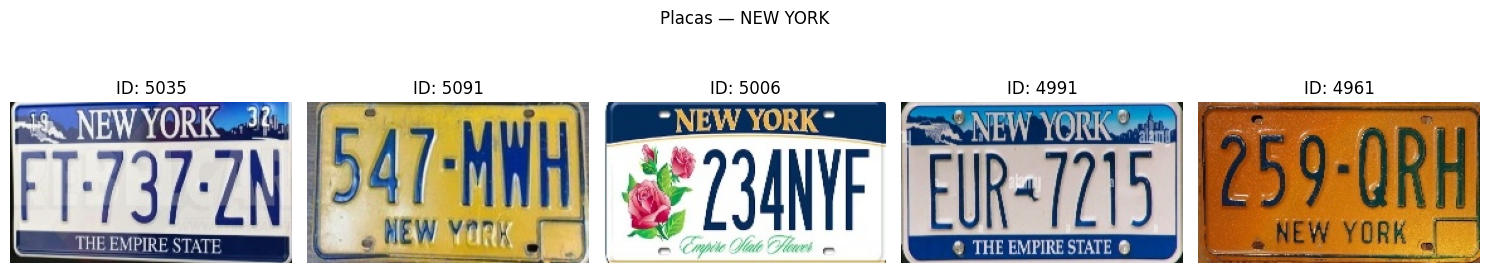

In [18]:
# Función de visualización y test — ejecutar sin modificar
import matplotlib.pyplot as plt
import random
import numpy as np

def visualize_state_plates(dataset, state_name, num_examples=5):
    """
    Muestra ejemplos de placas de un estado específico del dataset.

    Parámetros:
    dataset (PlatesDataSet): dataset de placas de matrícula
    state_name (str): nombre del estado en mayúsculas (ej. 'NEW YORK')
    num_examples (int): cantidad de imágenes a mostrar
    """
    indices = [i for i in range(len(dataset))
               if dataset.get_class_name(i).upper() == state_name.upper()]

    if not indices:
        available = sorted(set(dataset.text_labels))
        print(f"No se encontraron imágenes para '{state_name}'.")
        print(f"Estados disponibles: {', '.join(available)}")
        return

    selected = random.sample(indices, min(num_examples, len(indices)))
    fig, axes = plt.subplots(1, len(selected), figsize=(len(selected) * 3, 3))
    if len(selected) == 1:
        axes = [axes]

    for i, idx in enumerate(selected):
        image, _ = dataset[idx]
        img_np = image.permute(1, 2, 0).numpy() if isinstance(image, torch.Tensor) else np.array(image)
        axes[i].imshow(img_np)
        axes[i].set_title(f"ID: {idx}")
        axes[i].axis('off')

    plt.suptitle(f"Placas — {state_name.upper()}", y=1.02)
    plt.tight_layout()
    plt.show()


# Probar el dataset con el estado 'NEW YORK'
dataset_train = PlatesDataSet(mode='train', transform=transforms.ToTensor())
print(f"Imágenes de entrenamiento: {len(dataset_train)}")
visualize_state_plates(dataset_train, 'NEW YORK')

**Pregunta de análisis:**

¿Por qué PyTorch separa la lógica del dataset (`Dataset`) de la lógica del iterador por lotes (`DataLoader`)? ¿Qué ventaja tiene este diseño a la hora de experimentar con distintos tamaños de lote o estrategias de mezclado de datos?

*(Escribí tu respuesta acá)*

** Respuesta a la pregunta de análisis:**

La separación entre `Dataset` y `DataLoader` es un ejemplo del principio de responsabilidad única: cada clase hace una sola cosa.

- `Dataset` solo sabe cómo *acceder* a un elemento por su índice y cuántos elementos hay en total. No sabe nada de lotes, mezcla ni paralelismo.
- `DataLoader` solo sabe cómo *iterar* sobre un `Dataset`: agrupa los elementos en lotes, los mezcla, y puede cargarlos en paralelo con múltiples workers.

La ventaja práctica es que para cambiar el tamaño de lote, activar el mezclado o agregar workers de carga paralela, no hay que modificar nada de la clase de datos. Simplemente se instancia un nuevo `DataLoader` con los parámetros deseados: `DataLoader(dataset, batch_size=512, shuffle=True, num_workers=4)`. El mismo `PlatesDataSet` funciona sin cambios.

---
## Notas de corrección

| Ejercicio | Conceptos clave a evaluar | Errores frecuentes |
|---|---|---|
| 1 | `rand_like` vs `rand`, atributos `.shape/.dtype/.ndim/.numel()` | Usar `rand(2,3,4)` en lugar de `rand_like` |
| 2 | `.to()`, pérdida de precisión en conversión | No observar la diferencia numérica |
| 3 | Orden C (row-major), identificar posición de elemento | Confundir índice base 0 vs base 1 |
| 4 | `view`, indexación 3D, cálculo posición manual | Usar bucle para encontrar el 15 |
| 5 | Vista compartida, `.clone()` para copia real | No entender por qué cambia el cubo |
| 6 | Regla de broadcasting derecha a izquierda | Pensar que falla por diferente ndim |
| 7 | `reshape`/`unsqueeze` para alinear dimensiones | Forma incorrecta de v: `(6,1)` en vez de `(3,2,1)` |
| 8 | `view(1,3,1,1)` para normalización por canal | Intentar con bucle sobre las imágenes |
| 9 | `unsqueeze(1)` para crear columna, broadcasting bidireccional | No entender por qué `x.unsqueeze(1)` y no `x.unsqueeze(0)` |
| 10 | `requires_grad`, `.backward()`, `.grad`, `retain_graph` | No entender acumulación de gradientes |
| 12 | Herencia de `Dataset`, `__len__`, `__getitem__`, `get_class_name`. Cacheo de columnas como listas. `.convert('RGB')` | No llamar `super().__init__()`. Acceder al DataFrame en `__getitem__` en vez de a la lista cacheada. No usar `reset_index` al filtrar |

---
## ¡Listo! 

Completaste el Laboratorio 1a. En el próximo laboratorio usaremos todos estos conceptos como base para construir y entrenar redes neuronales reales sobre datos de imágenes.